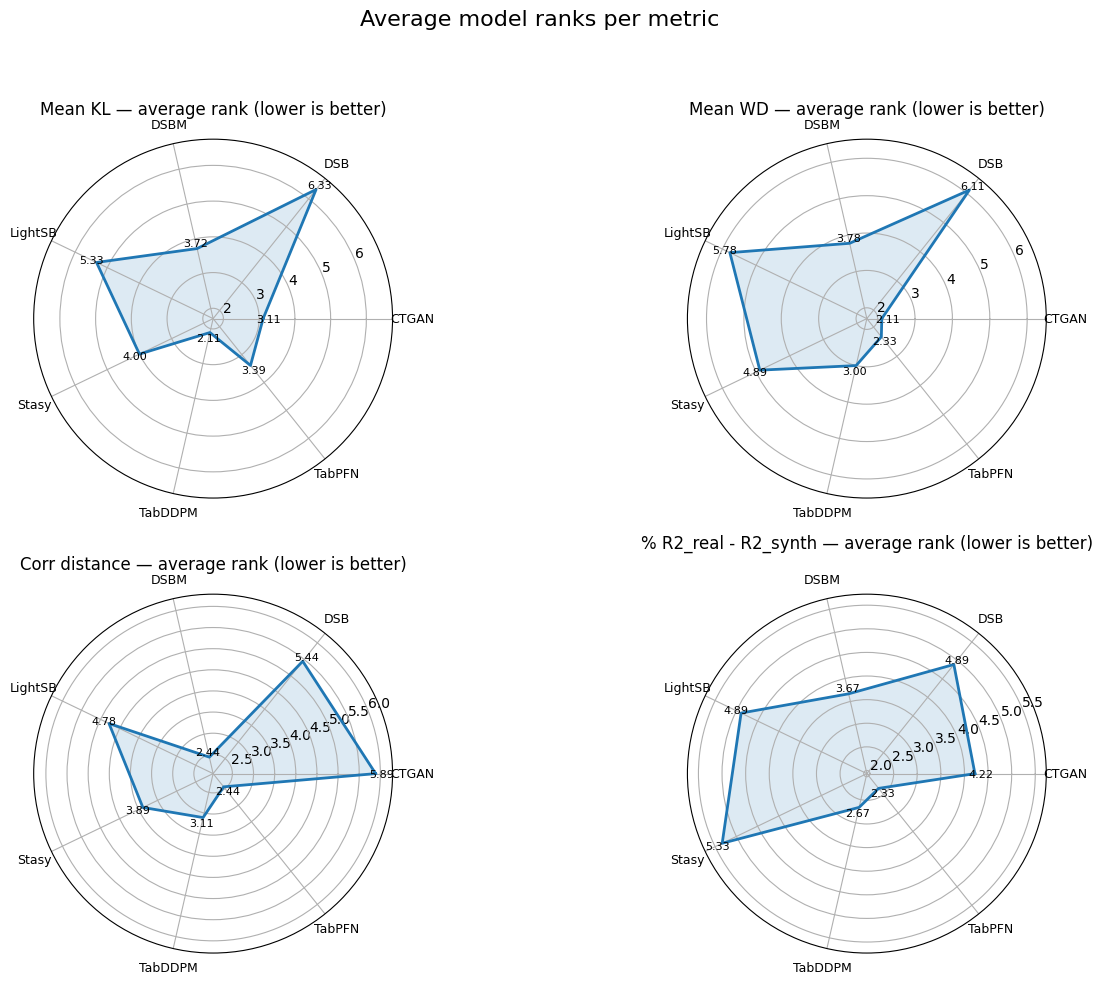

Saved: avg_rank_radar_charts_with_values.png

Average rank table (rows=models):

                      Mean KL   Mean WD  Corr distance  % R2_real - R2_synth
Генеративная модель                                                         
CTGAN                3.111111  2.111111       5.888889              4.222222
DSB                  6.333333  6.111111       5.444444              4.888889
DSBM                 3.722222  3.777778       2.444444              3.666667
LightSB              5.333333  5.777778       4.777778              4.888889
Stasy                4.000000  4.888889       3.888889              5.333333
TabDDPM              2.111111  3.000000       3.111111              2.666667
TabPFN               3.388889  2.333333       2.444444              2.333333


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def parse_mean_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
    return float(m.group(0)) if m else np.nan


def radar_plot(ax, labels, values, title, show_value_labels=True, value_fmt="{:.2f}"):
    labels = list(labels)
    values = np.asarray(values, dtype=float)

    # Angles
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
    angles_closed = np.concatenate([angles, [angles[0]]])
    vals_closed = np.concatenate([values, [values[0]]])

    # Plot
    ax.plot(angles_closed, vals_closed, linewidth=2)
    ax.fill(angles_closed, vals_closed, alpha=0.15)

    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title, pad=18)

    # Set radial limits (with padding)
    finite = values[np.isfinite(values)]
    if finite.size:
        vmin, vmax = float(np.min(finite)), float(np.max(finite))
        pad = 0.4
        ax.set_ylim(max(0.0, vmin - pad), vmax + pad)

    # Add numeric labels (avg ranks) near each vertex
    if show_value_labels:
        # Small outward offset proportional to current range
        finite = values[np.isfinite(values)]
        r_range = (np.max(finite) - np.min(finite)) if finite.size else 1.0
        offset = 0.03 * (r_range if r_range > 0 else 1.0) + 0.03

        for ang, r, lab in zip(angles, values, labels):
            if not np.isfinite(r):
                continue
            ax.text(
                ang,
                r + offset,
                value_fmt.format(r),
                ha="center",
                va="center",
                fontsize=8
            )


# -----------------------------
# Main
# -----------------------------
csv_path = "SB results - Лист1 (1).csv"
df = pd.read_csv(csv_path)

dataset_col = "Датасет"
model_col = "Генеративная модель"
metric_cols = [c for c in df.columns if c not in (dataset_col, model_col)]
if not metric_cols:
    raise ValueError("No metric columns found. Check your CSV headers.")

# Parse metric means
df_num = df.copy()
for c in metric_cols:
    df_num[c] = df_num[c].apply(parse_mean_value)

# Rank direction rules:
# - default: lower is better
# - if metric name contains "r2": rank by abs(value) (closer to 0 is better)
rank_mode = {c: ("abs" if "r2" in c.lower() else "min") for c in metric_cols}

# Compute average ranks per model for each metric
avg_ranks = {}
for metric in metric_cols:
    tmp = df_num[[dataset_col, model_col, metric]].dropna(subset=[metric]).copy()
    tmp["_score"] = tmp[metric].abs() if rank_mode[metric] == "abs" else tmp[metric]
    tmp["_rank"] = tmp.groupby(dataset_col)["_score"].rank(method="average", ascending=True)
    avg_ranks[metric] = tmp.groupby(model_col)["_rank"].mean()

# Stable model order across charts
all_models = sorted(set().union(*[s.index.tolist() for s in avg_ranks.values()]))

# Plot radar charts (one per metric)
n_metrics = len(metric_cols)
ncols = 2
nrows = int(np.ceil(n_metrics / ncols))

fig = plt.figure(figsize=(14, 10))
for i, metric in enumerate(metric_cols, start=1):
    ax = fig.add_subplot(nrows, ncols, i, polar=True)
    series = avg_ranks[metric].reindex(all_models)

    radar_plot(
        ax=ax,
        labels=all_models,
        values=series.values,
        title=f"{metric} — average rank (lower is better)",
        show_value_labels=True,
        value_fmt="{:.2f}"
    )

fig.suptitle("Average model ranks per metric", fontsize=16, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

# Save figure
out_path = "avg_rank_radar_charts_with_values.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
print("Saved:", out_path)

# Also print the average-rank table
rank_table = pd.DataFrame({m: avg_ranks[m] for m in metric_cols}).reindex(all_models)
print("\nAverage rank table (rows=models):\n")
print(rank_table)
